# Data Analysis Workshop - Main Analysis

**Data source:**
<https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2022.1050574/full>

This script performs the main statistical analyses for microbiome and
mycobiome data: <br>
- Principal Coordinates Analysis (PCoA) UniFrac distances <br> 
- Procrustes analysis to compare microbiome and
mycobiome ordinations <br>
- Canonical Correlation Analysis (CCA) to identify
co-varying taxa

## Library Installation

In [ ]:
# Please run the following code to install all necessary libraries, 
# unless you have already installed them using conda recipe: conda_recipes/r_libraries.yaml.

# R Library Installation Script
# Install required packages for microbiome analysis

# Install BiocManager if not already installed (needed for Bioconductor packages)
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Install Bioconductor packages
BiocManager::install("phyloseq")
BiocManager::install("GUniFrac")

# Install CRAN packages
install.packages("vegan")
install.packages("ape")
install.packages("ggplot2")
install.packages("ggpubr")
install.packages("PMA")
install.packages("reshape2")
install.packages("tidyr")
install.packages("phytools")
install.packages("compositions")

# Verify installations by loading libraries
cat("\n=== Verifying installations ===\n")
libraries <- c("phyloseq", "vegan", "ape", "ggplot2", "ggpubr", 
               "PMA", "parallel", "reshape2", "tidyr", "GUniFrac", "phytools", "compositions")

for (lib in libraries) {
  if (require(lib, character.only = TRUE, quietly = TRUE)) {
    cat(sprintf("✓ %s loaded successfully\n", lib))
  } else {
    cat(sprintf("✗ %s failed to load\n", lib))
  }
}

cat("\nInstallation complete!\n")

## Load Libraries

In [1]:
# Load necessary libraries for microbiome analysis
library(phyloseq)    # For microbiome data handling
library(vegan)       # For ecological diversity analysis
library(ape)         # For phylogenetic tree manipulation
library(ggplot2)     # For visualization
library(ggpubr)      # For publication-ready plots
library(PMA)         # For sparse CCA
library(parallel)    # For parallel computing
library(reshape2)    # For data reshaping
library(tidyr)       # For data tidying
library(GUniFrac)    # For UniFrac distance calculations
library(phytools)    # For phylogenetic tree tools
library(compositions) # For CLR transformation

Loading required package: permute

Loading required package: lattice

This is vegan 2.6-4


Attaching package: ‘ggpubr’


The following object is masked from ‘package:ape’:

    rotate



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:vegan’:

    scores


Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following object is masked from ‘package:ape’:

    balance


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




### Custom ggplot theme

In [8]:
custom_theme <- theme_light() +
      theme(axis.text=element_text(size=20),
          axis.title=element_text(size=20), 
          plot.title=element_text(size=20, face="bold"),
          plot.subtitle=element_text(size=20, face="plain"),
          plot.caption = element_text(face = "italic"),
          text = element_text(size = 20), 
          legend.title=element_text(size=20),
          legend.text=element_text(size=20),
          axis.line = element_line(color = "darkgrey")) 

## Load Data

# PCoA based on UniFrac Distances

UniFrac distances incorporate phylogenetic relationships between taxa.
This analysis requires phylogenetic trees (generated in file 2).

In [2]:
# Load phyloseq objects with phylogenetic trees
ps_microbiome_with_tree <- readRDS('../../data/data_analysis/ps_microbiome.filtered.rds')
ps_mycobiome_with_tree  <- readRDS('../../data/data_analysis/ps_mycobiome.filtered.rds')

ps_microbiome_with_tree
ps_mycobiome_with_tree

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 14691 taxa and 343 samples ]
sample_data() Sample Data:       [ 343 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 14691 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 14691 tips and 14689 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 343 samples ]
sample_data() Sample Data:       [ 343 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 6159 tips and 6159 internal nodes ]

In [3]:
# Root the phylogenetic tree at midpoint for consistency
phy_tree(ps_microbiome_with_tree) <- midpoint.root(phy_tree(ps_microbiome_with_tree))
phy_tree(ps_mycobiome_with_tree) <- midpoint.root(phy_tree(ps_mycobiome_with_tree))

In [4]:
# Calculate UniFrac distances
# alpha=0: unweighted, alpha=0.5: compromise, alpha=1: weighted
unifrac_microbiome <- GUniFrac(otu_table(ps_microbiome_with_tree), 
                               phy_tree(ps_microbiome_with_tree), 
                               alpha = c(0, 0.5, 1))$unifracs

unifrac_mycobiome <- GUniFrac(otu_table(ps_mycobiome_with_tree), 
                               phy_tree(ps_mycobiome_with_tree), 
                               alpha = c(0, 0.5, 1))$unifracs

saveRDS(unifrac_microbiome, "../../data/data_analysis/unifrac_microbiome.rds")
saveRDS(unifrac_mycobiome, "../../data/data_analysis/unifrac_mycobiome.rds")

Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!
Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!


In [5]:
unifrac_microbiome <- readRDS("../../data/data_analysis/unifrac_microbiome.rds")
unifrac_mycobiome <- readRDS("../../data/data_analysis/unifrac_mycobiome.rds")

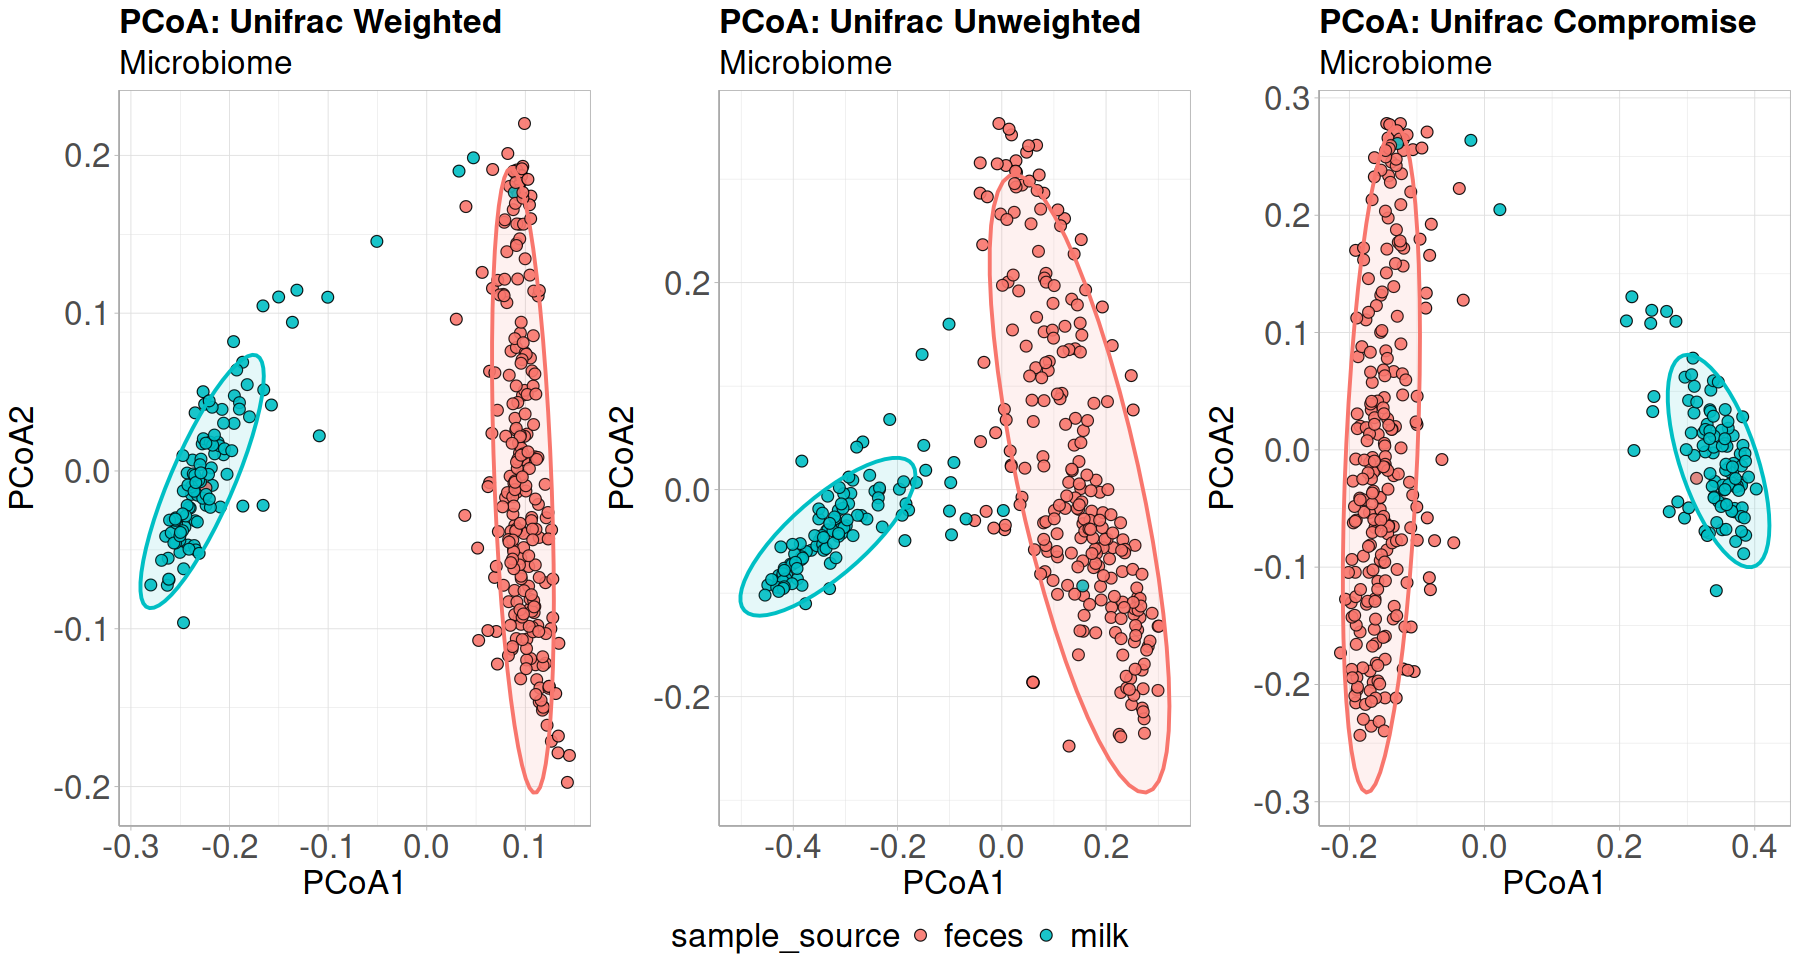

In [10]:
unifrac_types <- list(Weighted='d_1', Unweighted='d_UW', Compromise='d_0.5')
pcoa_plots <- lapply(names(unifrac_types), function(unifrac_type) {
    dist <- unifrac_microbiome[, , unifrac_types[[unifrac_type]]]
    # compute pcoa
    pcoa_res_microbiome <- pcoa(dist)

    # reformat the result table for plotting with ggplot
    pcoa_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
    colnames(pcoa_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
    pcoa_coordinates_microbiome <- cbind(pcoa_coordinates_microbiome, sample_data(ps_microbiome_with_tree))
    pcoa_coordinates_microbiome$sample_type <- 'Microbiome' 
    
    
    p <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    # plot sample values projected on PCoA
          geom_point(aes(fill = sample_source), 
                     size = 3, alpha=0.9, pch=21) +
    # plot group circles
          stat_ellipse(geom = "polygon",
                       aes(color = sample_source, 
                           fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
    # add titles
          labs(
               title = paste0("PCoA: Unifrac ", unifrac_type), 
               subtitle = "Microbiome") +
    # custom plot design
          custom_theme
    return(p)
})

# combine figures together
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)
p_combined <- ggarrange(pcoa_plots[[1]], pcoa_plots[[2]], pcoa_plots[[3]],
          ncol = 3, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p_combined)

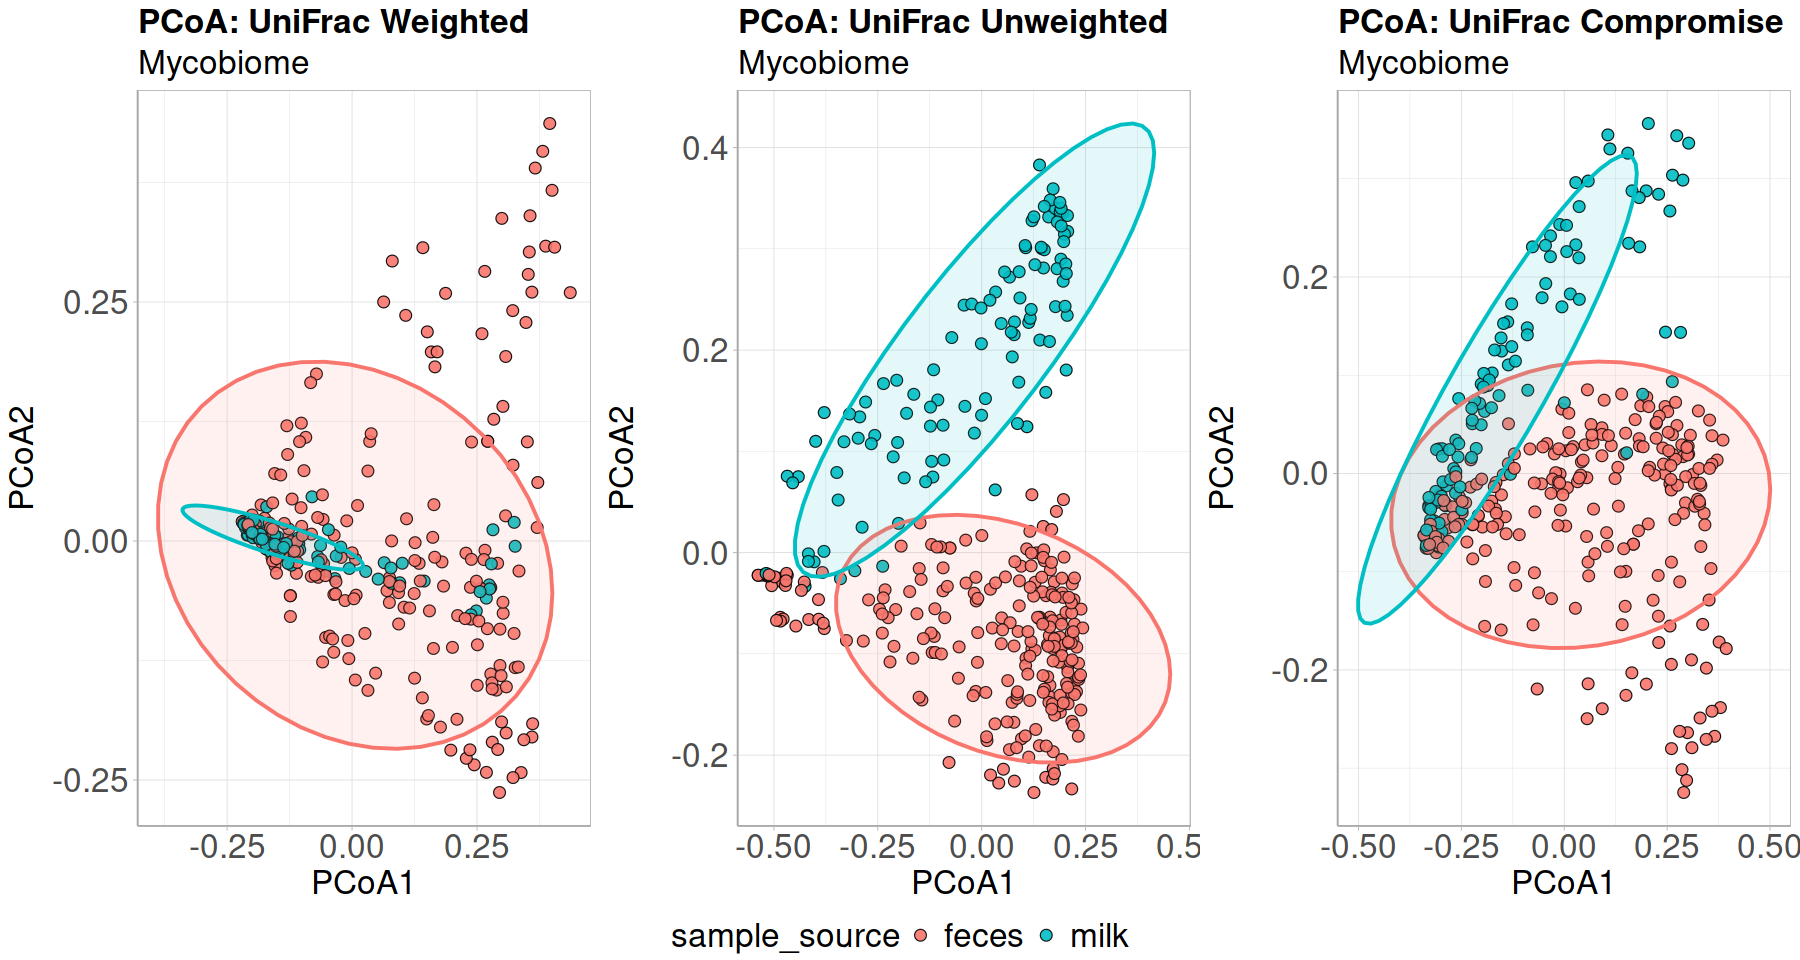

In [9]:
# Create PCoA plots for all three UniFrac variants
unifrac_types <- list(Weighted='d_1', Unweighted='d_UW', Compromise='d_0.5')

pcoa_plots <- lapply(names(unifrac_types), function(unifrac_type) {
    # Extract distance matrix for this UniFrac type
    dist <- unifrac_mycobiome[, , unifrac_types[[unifrac_type]]]
    
    # Perform PCoA
    pcoa_res_mycobiome <- pcoa(dist)

    # Extract coordinates
    pcoa_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
    colnames(pcoa_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
    pcoa_coordinates_mycobiome <- cbind(pcoa_coordinates_mycobiome, sample_data(ps_mycobiome_with_tree))
    pcoa_coordinates_mycobiome$sample_type <- 'Mycobiome' 
    
    # Create plot
    p <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
        geom_point(aes(fill = sample_source), 
                   size = 3, alpha=0.9, pch=21) +
        stat_ellipse(geom = "polygon",
                     aes(color = sample_source, 
                         fill = after_scale(alpha(colour, 0.1))), 
                     lwd=1.1, level=0.9, show.legend = FALSE) +
        labs(title = paste0("PCoA: UniFrac ", unifrac_type), 
             subtitle = "Mycobiome") +
        custom_theme
    return(p)
})

# Combine all three plots
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p_combined <- ggarrange(pcoa_plots[[1]], pcoa_plots[[2]], pcoa_plots[[3]],
          ncol = 3, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p_combined)

# Procrustes Analysis for PCoA Unweighted UniFrac

**About Procrustes Analysis:** "Procrustes analysis is named after a
bandit from ancient Greek mythology that would hunt people down, and
adjust their sizes to his iron bed by either cutting their limbs off or
stretching them."

**Citation source:**
[https://medium.com/\@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421](https://medium.com/@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421){.uri}

**Figure source:**
<https://www.scielo.br/j/brag/a/w4DBp6nzxwvPFDR7JYWGWDr/?lang=en>

Procrustes analysis tests whether two ordinations have similar
structures by rotating, translating, and scaling one to match the other.

![Procrustes](https://minio.scielo.br/documentstore/1678-4499/w4DBp6nzxwvPFDR7JYWGWDr/fe4b2ee3c20d0671acaeb9176a3a4705df41e0d7.jpg)

In [11]:
dist <- unifrac_microbiome[, , unifrac_types[['Unweighted']]]
# compute pcoa
pcoa_res_microbiome <- pcoa(dist)

# reformat the result table for plotting with ggplot
pcoa_unifrac_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_unifrac_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
pcoa_unifrac_coordinates_microbiome <- cbind(pcoa_unifrac_coordinates_microbiome, sample_data(ps_microbiome_with_tree))
pcoa_unifrac_coordinates_microbiome$sample_type <- 'Microbiome' 

In [12]:
dist <- unifrac_mycobiome[, , unifrac_types[['Unweighted']]]
# compute pcoa
pcoa_res_mycobiome <- pcoa(dist)

# reformat the result table for plotting with ggplot
pcoa_unhifrac_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_unhifrac_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
pcoa_unhifrac_coordinates_mycobiome <- cbind(pcoa_unhifrac_coordinates_mycobiome, sample_data(ps_mycobiome_with_tree))
pcoa_unhifrac_coordinates_mycobiome$sample_type <- 'Mycobiome' 

In [13]:
# Combine microbiome and mycobiome coordinates for visualization
pcoa_coordinates <- rbind(pcoa_unifrac_coordinates_microbiome,
                          pcoa_unhifrac_coordinates_mycobiome)

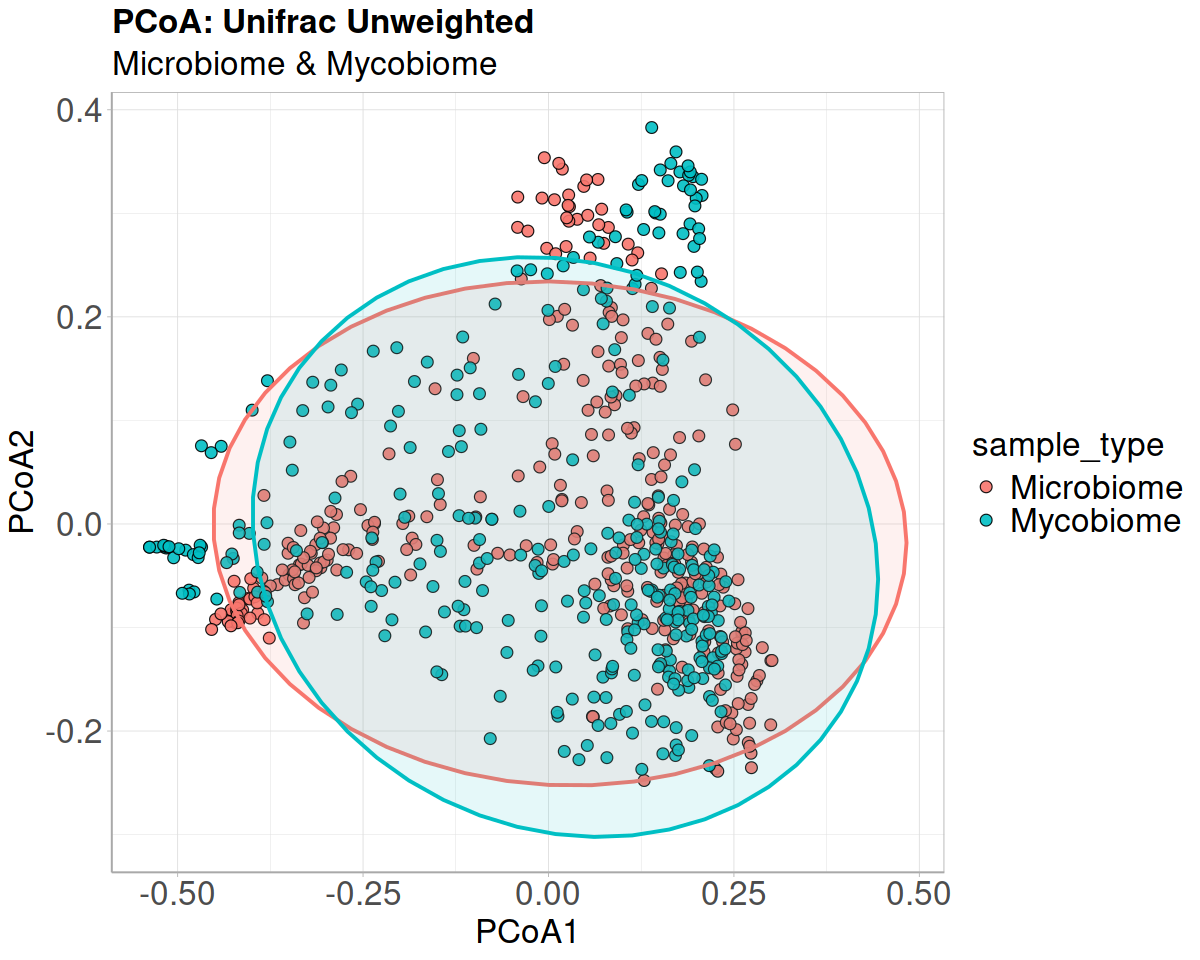

In [14]:
# Plot both datasets together before Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_type), 
               size = 3, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_type, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Unifrac Unweighted", 
         subtitle = "Microbiome & Mycobiome") +
    custom_theme 

pcoa_plot

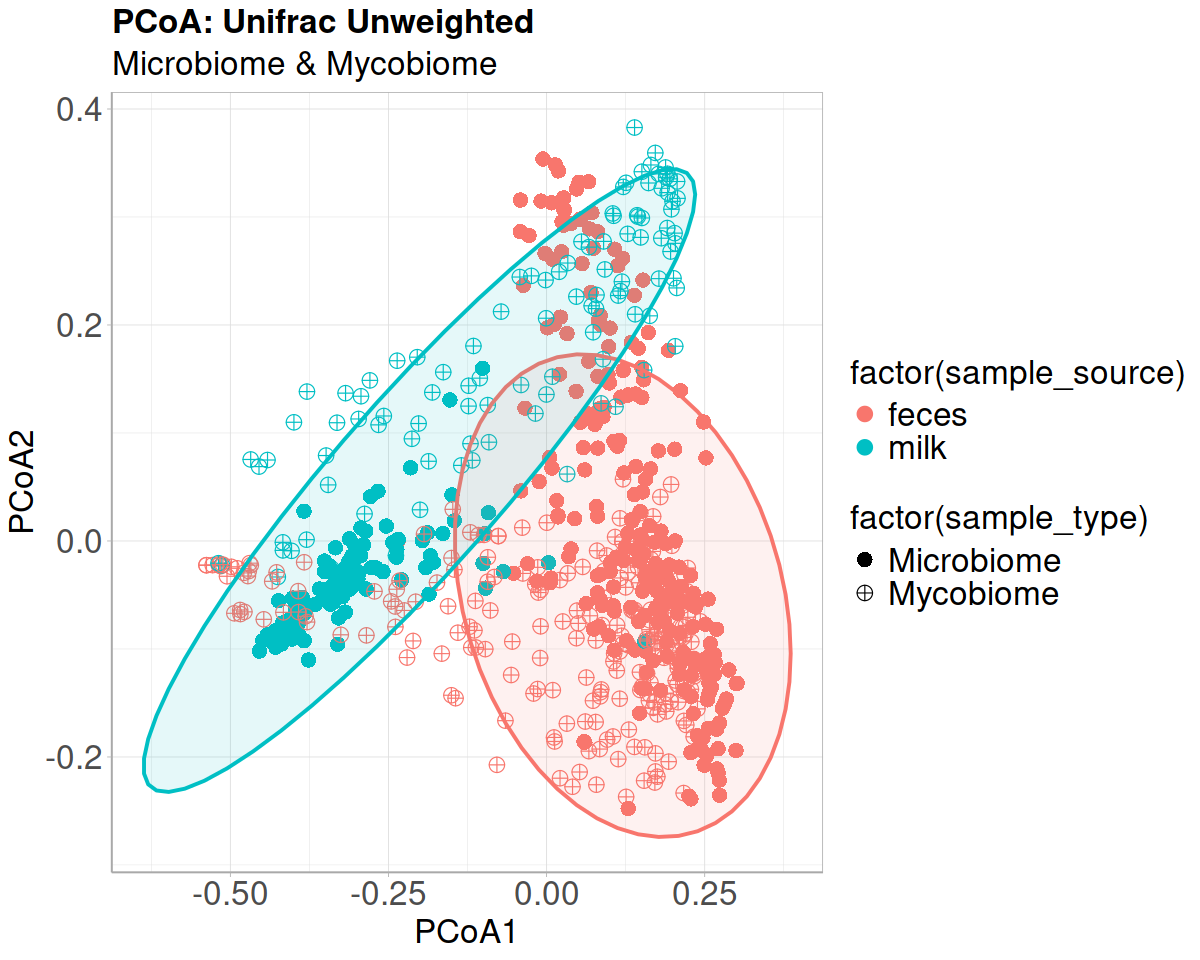

In [22]:
# Plot both datasets together before Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(color=factor(sample_source), shape=factor(sample_type)), 
               size = 4, alpha=1) +
    scale_shape_manual(values = c(16, 10)) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Unifrac Unweighted", 
         subtitle = "Microbiome & Mycobiome") +
    custom_theme

pcoa_plot

In [23]:
# Perform Procrustes transformation
# Use all available dimensions for more robust comparison
n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))

procrustes_res <- procrustes(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                             data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                             scale=FALSE)

In [24]:
# Extract rotated coordinates for plotting
pcoa_rotated_mycobiome <- data.frame(procrustes_res$Yrot)
colnames(pcoa_rotated_mycobiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome <- data.frame(procrustes_res$X)
colnames(pcoa_original_microbiome) <- paste0('PCoA', c(1:n))

pcoa_original_microbiome$sample_type <- 'Microbiome'
pcoa_rotated_mycobiome$sample_type <- 'Mycobiome'
pcoa_original_microbiome <- cbind(pcoa_original_microbiome, sample_data(ps_microbiome_with_tree))
pcoa_rotated_mycobiome <- cbind(pcoa_rotated_mycobiome, sample_data(ps_mycobiome_with_tree))

pcoa_coordinates_procrustes <- rbind(pcoa_original_microbiome, pcoa_rotated_mycobiome)

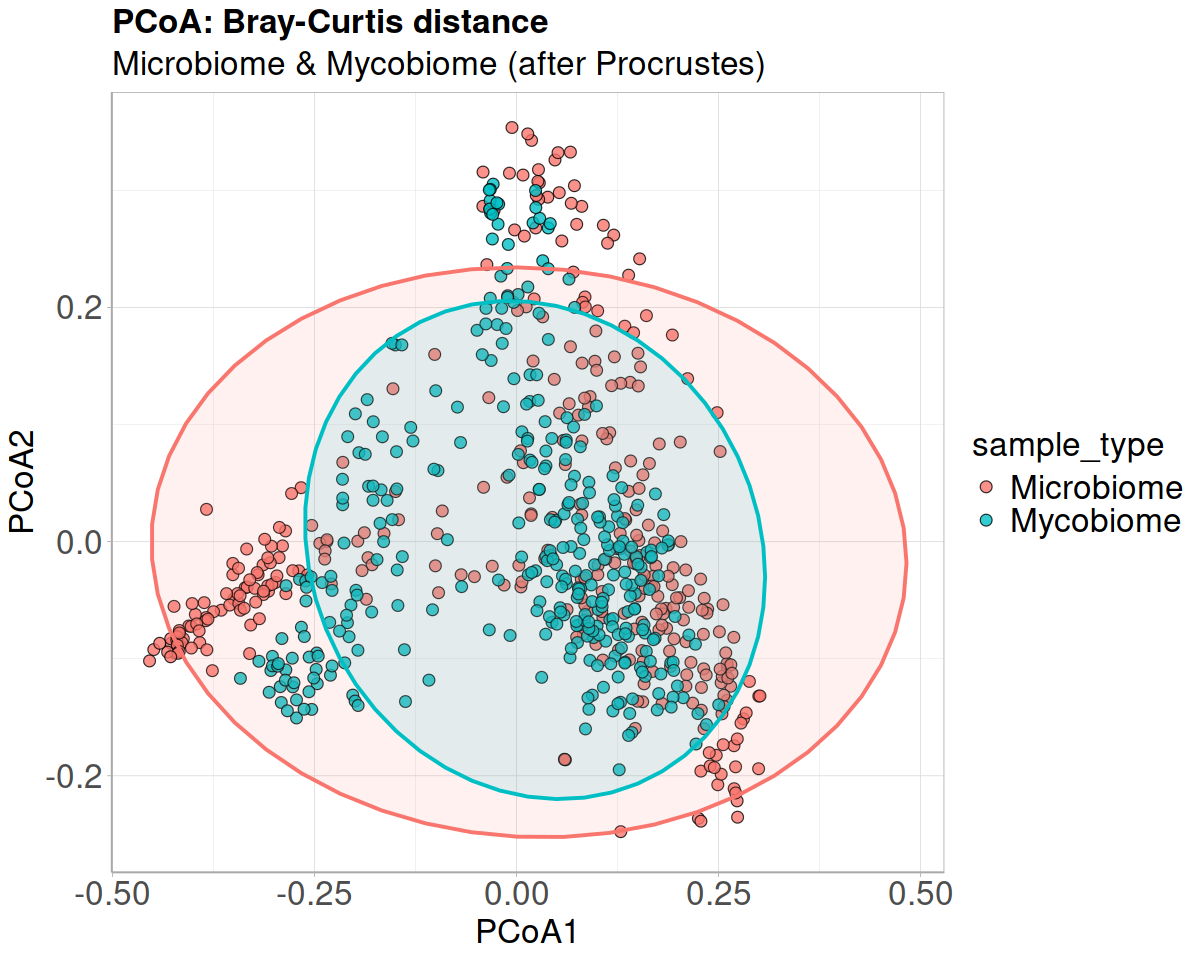

In [25]:
# Plot after Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_type), 
               size = 3, alpha=0.8, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_type, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome & Mycobiome (after Procrustes)") +
    custom_theme

pcoa_plot

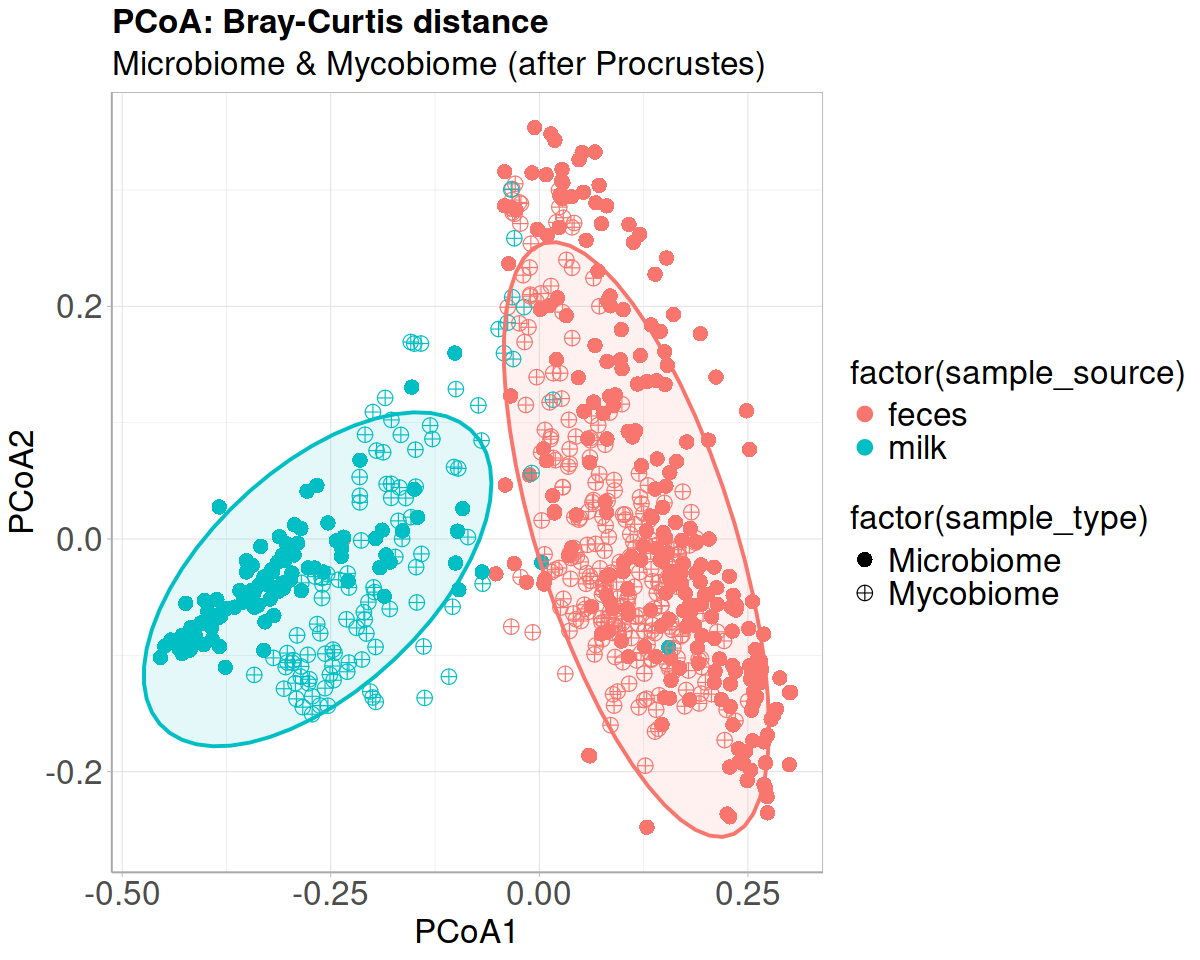

In [27]:
# Plot after Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(color=factor(sample_source), shape=factor(sample_type)), 
               size = 4, alpha=1) +
    scale_shape_manual(values = c(16, 10)) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome & Mycobiome (after Procrustes)") +
    custom_theme

pcoa_plot

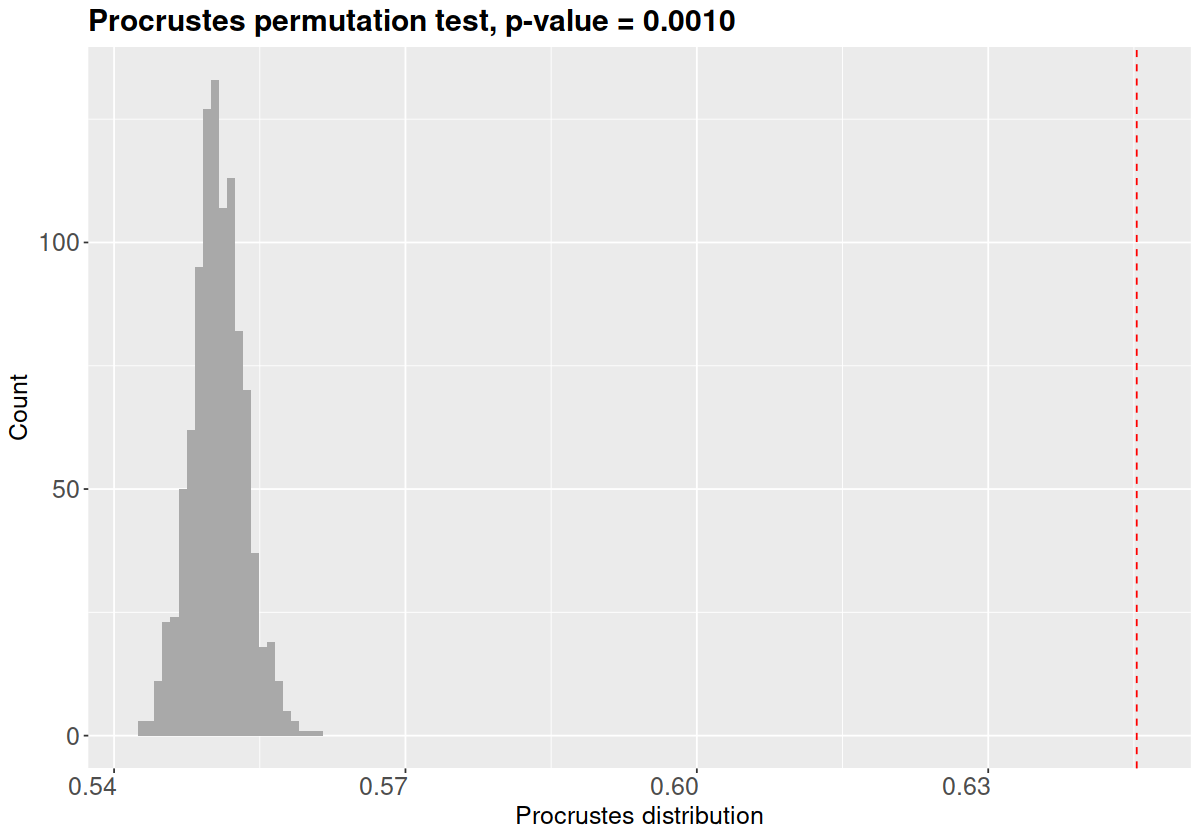

In [28]:
# Perform permutation test to assess significance
width = 10
height = 7
options(repr.plot.width=width, repr.plot.height=height)

n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))

set.seed(123)  # For reproducibility
procrustes_permutation <- protest(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                                  data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                                  scale=FALSE, permutations = 999)

# Extract permutation distribution
procrustes_permutation_d <- data.frame(distances = procrustes_permutation$t)
procrustes_permutation_d0 <- procrustes_permutation$t0

# Plot permutation test results
procrustes_dist_plot <- ggplot(data = procrustes_permutation_d, aes(x = distances)) +
    geom_histogram(bins = 125, fill = "dark grey") +
    geom_vline(xintercept = procrustes_permutation_d0, lty = 2, color = "red") +
    labs(x = "Procrustes distribution", y = "Count") +
    theme(axis.text.x = element_text(hjust = 0.95, vjust=0.95),
          axis.text=element_text(size=15),
          axis.title=element_text(size=15),
          plot.title=element_text(size=18, face="bold")) + 
    theme(legend.position = "none") +
    ggtitle(paste0('Procrustes permutation test, p-value = ', 
                   sprintf('%.4f', procrustes_permutation$signif)))

procrustes_dist_plot

# Canonical Correlation Analysis (CCA)

CCA identifies linear combinations of taxa from microbiome and mycobiome
that are maximally correlated with each other.

Reference:
<https://github.com/blekhmanlab/host_gene_microbiome_interactions/blob/main/Tutorial/README.md>

In [29]:
# Function to tune CCA penalty parameters using grid search
# Penalties control sparsity (feature selection)
tune_params_grid_search <- function(X, Y, 
                                    penaltyX=seq(0.1,0.3,length=5), 
                                    penaltyY=seq(0.1,0.3,length=5), 
                                    nfolds = NULL){
    num_samples <- nrow(X)
    if (is.null(nfolds)) {
      nfolds = num_samples
    }
    start_time <- Sys.time()
    
    # Create grid of parameter combinations
    params <- expand.grid(c(1:length(penaltyX)), c(1:length(penaltyY)))  
    set.seed(45)
    folds <- sample(rep_len(1:nfolds, num_samples))
    
    # Test each parameter combination using cross-validation
    corr_demo <- mclapply(c(1:dim(params)[1]), function(x){
        i <- params[x, 'Var1']
        j <- params[x, 'Var2']
        scoreXcv <- c()
        scoreYcv <- c()
        
        # Leave-one-out cross-validation
        score_cv <- lapply(c(1:nfolds), function(k){
            train_data_inds <- folds != k
            test_data_inds <- folds == k
            # Compute weights with sample k held out
            res <- CCA(X[train_data_inds,], Y[train_data_inds,], 
                      typex="standard", typez="standard",
                      penaltyx = penaltyX[i], penaltyz = penaltyY[j], 
                      K=1, niter = 12, trace = FALSE, standardize = TRUE)
            
            # Compute scores for held-out sample
            return(data.frame(k=k, 
                              scoreXcv=X[test_data_inds,]%*%res$u, 
                              scoreYcv=Y[test_data_inds,]%*%res$v))
        })
        score_cv <- do.call('rbind', score_cv)
        
        # Correlation between scores for X and Y
        return(cor(score_cv$scoreXcv, score_cv$scoreYcv))
    }, mc.cores=detectCores())
    
    corr_demo <- unlist(corr_demo)
    
    # Select parameters with best correlation
    best <- which.max(corr_demo)
    bestpenaltyX <- penaltyX[params[best, 'Var1']]
    bestpenaltyY <- penaltyY[params[best, 'Var2']]
    
    return(c(bestpenaltyX, bestpenaltyY))
}

In [30]:
# Function to run sparse CCA
run_sparseCCA <- function(X, Z, CCA.K, penaltyX, penaltyZ){
  CCA.out <-  CCA(X,Z,typex="standard",typez="standard",K=CCA.K,
                  penaltyx=penaltyX,penaltyz=penaltyZ)
  
  ## add rownames to output factors
  rownames(CCA.out$u) <- colnames(X)
  rownames(CCA.out$v) <- colnames(Z)
  ## compute contribution of selected features to each of the samples.
  CCA_var_genes <- X %*% CCA.out$u ## canonical variance for genes 
  CCA_var_microbes <- Z %*% CCA.out$v ## canonical variance for microbes
  
  return(list(CCA.out, CCA_var_genes, CCA_var_microbes))
}

In [31]:
# Function to test CCA significance using cross-validation
test_significance_LOOCV <- function(X, Y, K, penaltyX, penaltyY){
    num_samples <- nrow(X)
    corr_pval <- c()
    
    for (j in c(1:K)){
        scoreXcv <- c()
        scoreYcv <- c()
        
        # Leave-one-out cross-validation
        for (k in c(1:num_samples)){
            res <- CCA(X[-k,], Y[-k,], 
                      typex="standard", typez="standard",
                      penaltyx = penaltyX, penaltyz = penaltyY, 
                      K=K, niter = 12, trace = FALSE, standardize = TRUE)
            
            scoreXcv[k] <- X[k,] %*% res$u[,j]
            scoreYcv[k] <- Y[k,] %*% res$v[,j]
        }
        
        # Test correlation significance
        corr <- cor.test(scoreXcv, scoreYcv)
        corr_pval[j] <- corr$p.value
    }
    return(corr_pval)
}

In [32]:
# Load phyloseq objects containing microbiome (16S) and mycobiome (ITS) data
ps_microbiome <- readRDS('../../data/data_analysis/ps_microbiome.genus_agglomerated.rds')
ps_mycobiome <- readRDS('../../data/data_analysis/ps_mycobiome.genus_agglomerated.rds')

# Display summary of loaded objects
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 632 tips and 631 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 140 tips and 139 internal nodes ]

In [33]:
# Filter out rarely present taxa (present in <1% of samples)
otu_microbiome <- data.frame(otu_table(ps_microbiome))
otu_mycobiome <- data.frame(otu_table(ps_mycobiome))

otu_microbiome <- otu_microbiome[, colSums(otu_microbiome != 0)/nrow(otu_microbiome) > 0.01]
otu_mycobiome <- otu_mycobiome[, colSums(otu_mycobiome != 0)/nrow(otu_mycobiome) > 0.01]

otu_microbiome <- clr(otu_microbiome)
otu_mycobiome <- clr(otu_mycobiome)

dim(otu_microbiome)
dim(otu_mycobiome)

[1] 335 200

[1] 335  37

In [34]:
# Find optimal penalty parameters
bestPenalty <- tune_params_grid_search(as.matrix(otu_microbiome), 
                                       as.matrix(otu_mycobiome), 
                                       nfolds=10)
bestpenaltyX <- bestPenalty[1]
bestpenaltyY <- bestPenalty[2]

In [35]:
# Run CCA with optimal parameters
cca.k = 5  # Number of canonical components to extract
cca_results <- run_sparseCCA(as.matrix(otu_microbiome), 
                             as.matrix(otu_mycobiome), 
                             cca.k, 
                             bestpenaltyX, bestpenaltyY)

123456789101112131415
12345678910111213
1234567
123456789
12345678910


In [36]:
# Test significance of each component
CCA_pval <- test_significance_LOOCV(as.matrix(otu_microbiome), 
                                   as.matrix(otu_mycobiome),
                                   cca.k, 
                                   bestpenaltyX, bestpenaltyY)

# Adjust for multiple testing
CCA_padj <- p.adjust(CCA_pval, method = "BH")
saveRDS(CCA_padj, '../../data/data_analysis/CCA_padj.rds')

In [37]:
CCA_padj <- readRDS('../../data/data_analysis/CCA_padj.rds')

In [38]:
# Prepare data for visualization
# Extract microbiome component scores
components_microbiome <- as.data.frame(cca_results[[2]])
colnames(components_microbiome) <- sprintf("Comp%02d", 1:cca.k)
components_microbiome$sample <- rownames(components_microbiome)
components_microbiome <- pivot_longer(components_microbiome, 
                                     cols = !sample, 
                                     names_to = "component", 
                                     values_to = "Microbiome")

# Extract mycobiome component scores
components_mycobiome <- as.data.frame(cca_results[[3]])
colnames(components_mycobiome) <- sprintf("Comp%02d", 1:cca.k)
components_mycobiome$sample <- rownames(components_mycobiome)
components_mycobiome <- pivot_longer(components_mycobiome, 
                                     cols = !sample, 
                                     names_to = "component", 
                                     values_to = "Mycobiome")

# Combine into single dataframe
df_comp <- cbind(components_microbiome, components_mycobiome$Mycobiome)
df_comp <- as.data.frame(df_comp)
colnames(df_comp) <- c("sample", "component", "Microbiome", "Mycobiome")

In [39]:
# Extract feature coefficients (taxa loadings)
# Microbiome coefficients
coefficients_microbiome <- data.frame(cca_results[[1]]$u)
colnames(coefficients_microbiome) <- sprintf("Comp%02d", 1:cca.k)
coefficients_microbiome$taxa <- row.names(coefficients_microbiome)
coefficients_microbiome <- pivot_longer(coefficients_microbiome, 
                                       cols = !taxa, 
                                       names_to = "component", 
                                       values_to = "coefficient")
# Keep only non-zero coefficients (sparse CCA sets many to zero)
coefficients_microbiome <- coefficients_microbiome[coefficients_microbiome$coefficient != 0, ]

# Mycobiome coefficients
coefficients_mycobiome <- data.frame(cca_results[[1]]$v)
colnames(coefficients_mycobiome) <- sprintf("Comp%02d", 1:cca.k)
coefficients_mycobiome$taxa <- row.names(coefficients_mycobiome)
coefficients_mycobiome <- pivot_longer(coefficients_mycobiome, 
                                      cols = !taxa, 
                                      names_to = "component", 
                                      values_to = "coefficient")
coefficients_mycobiome <- coefficients_mycobiome[coefficients_mycobiome$coefficient != 0, ]

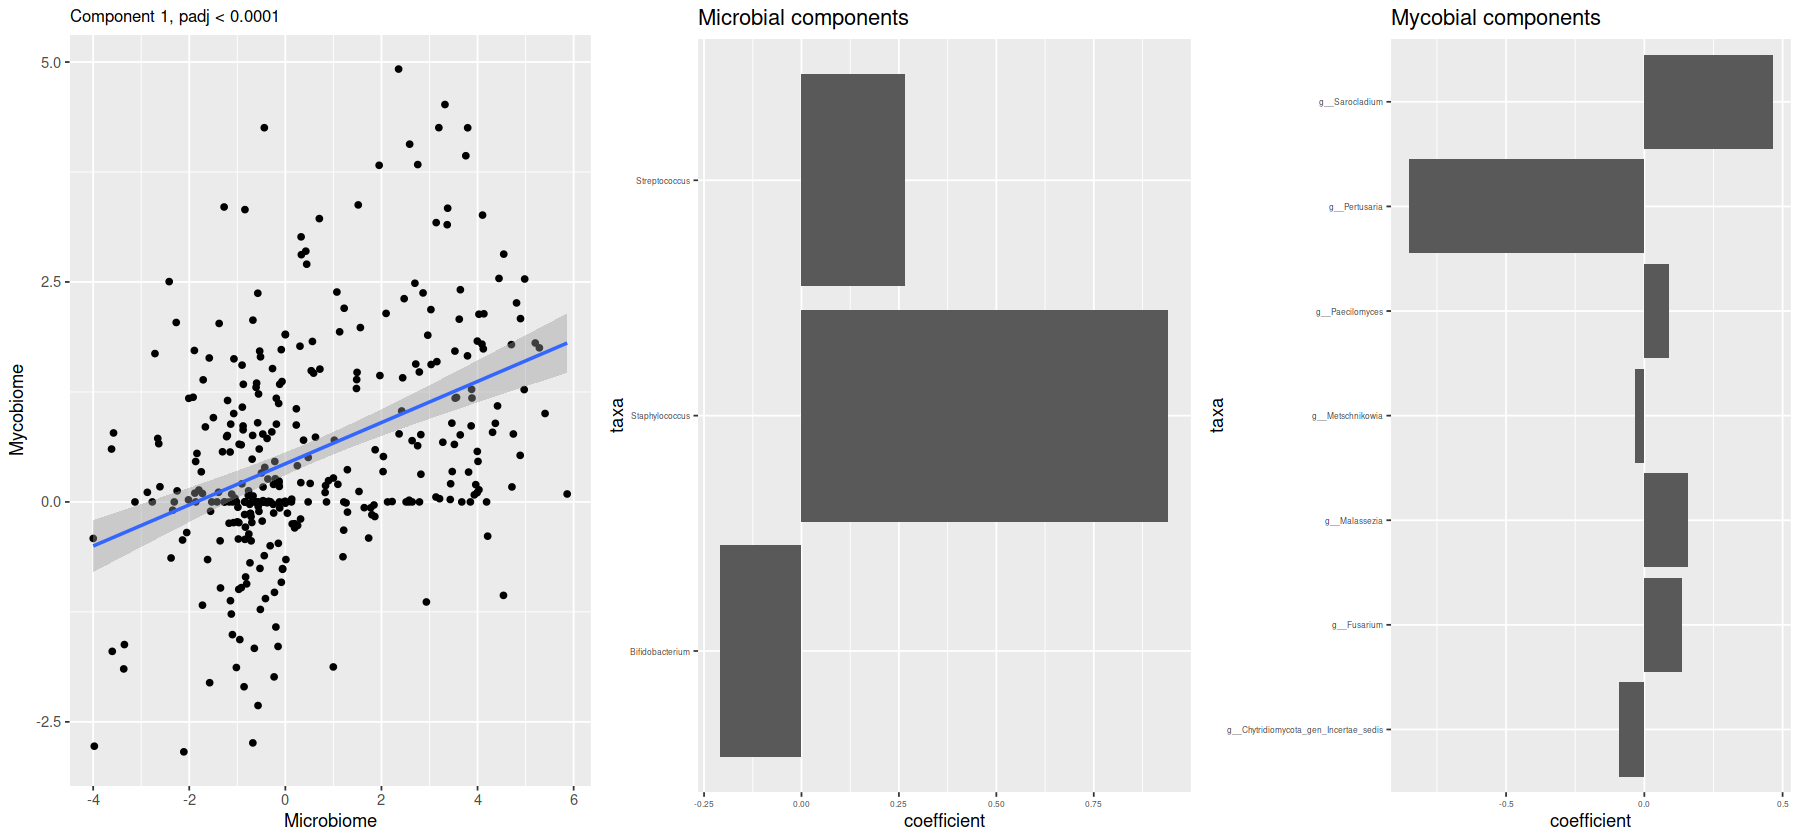

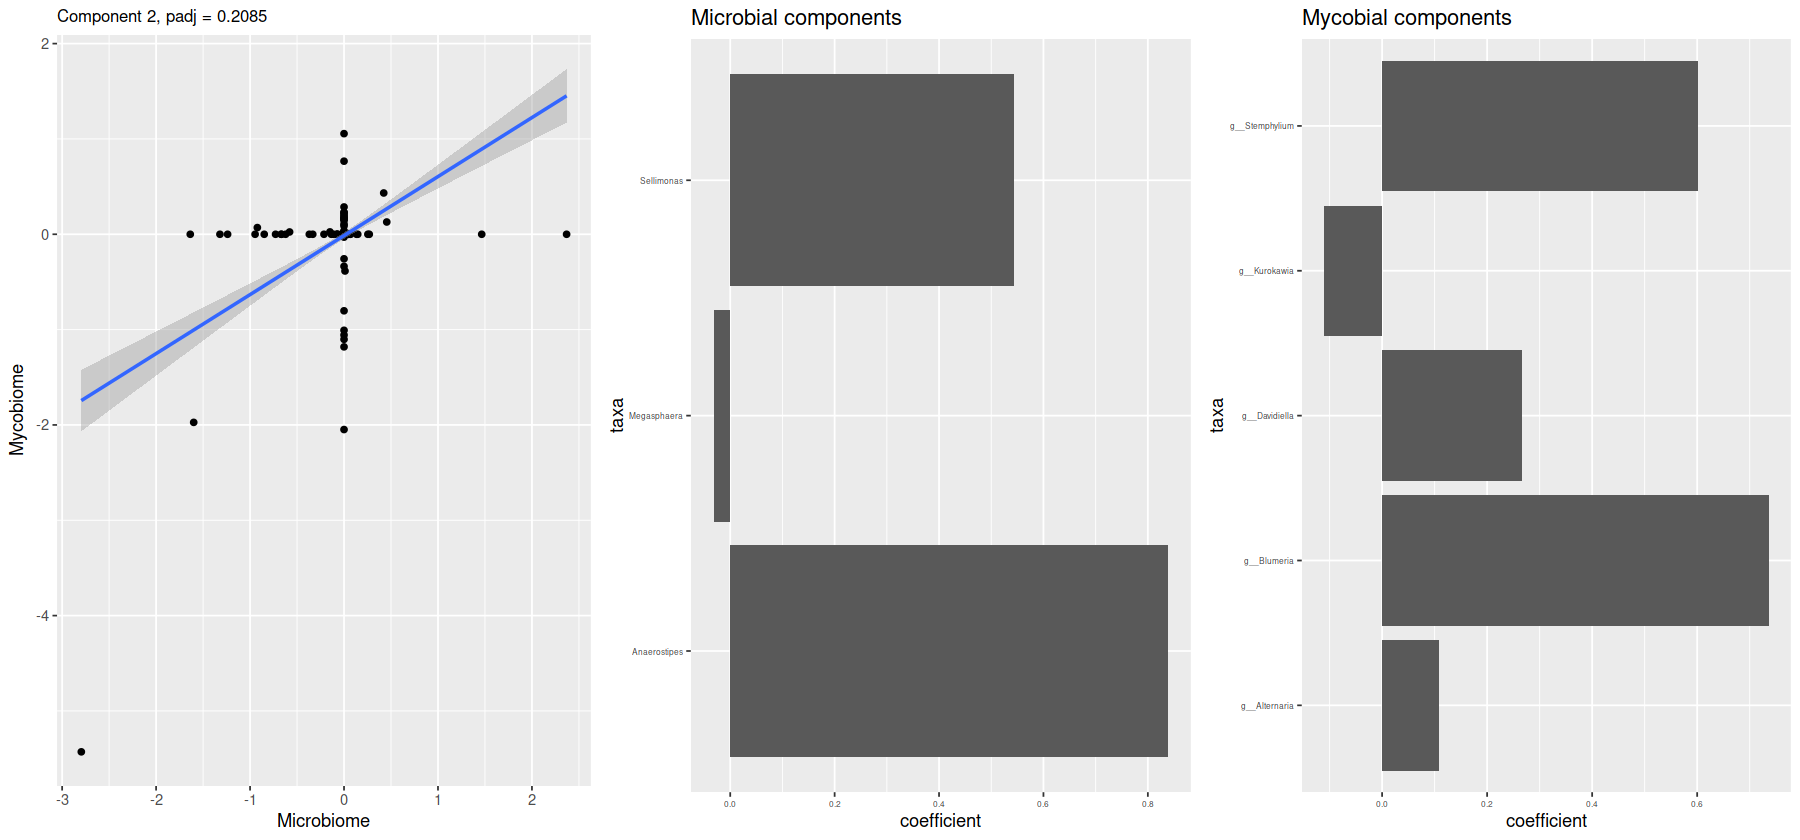

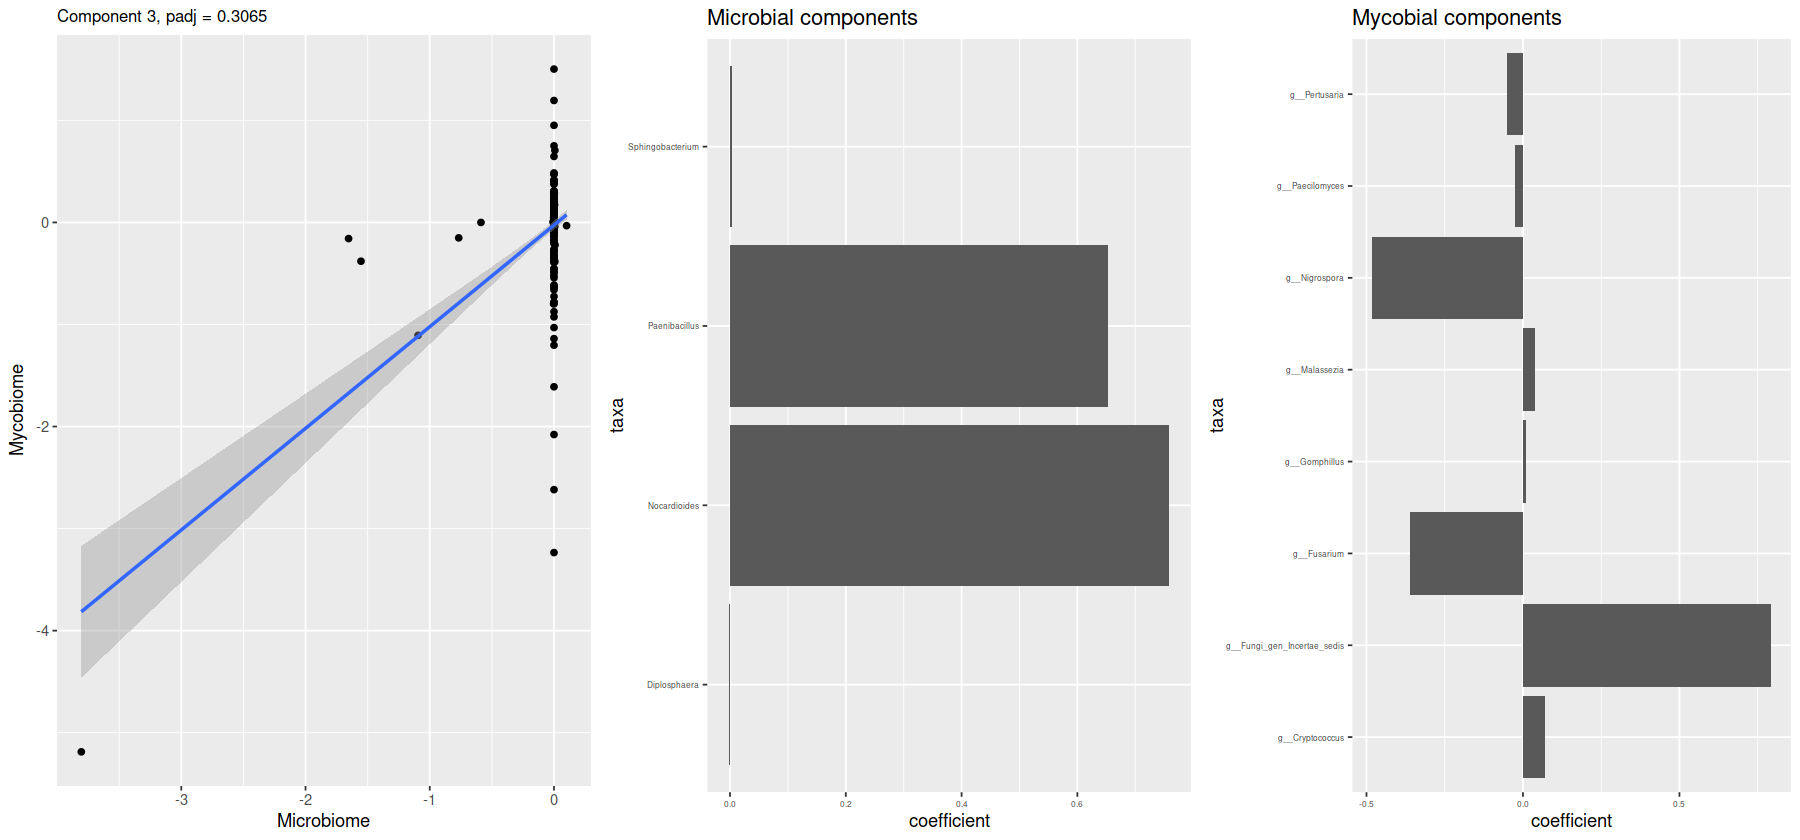

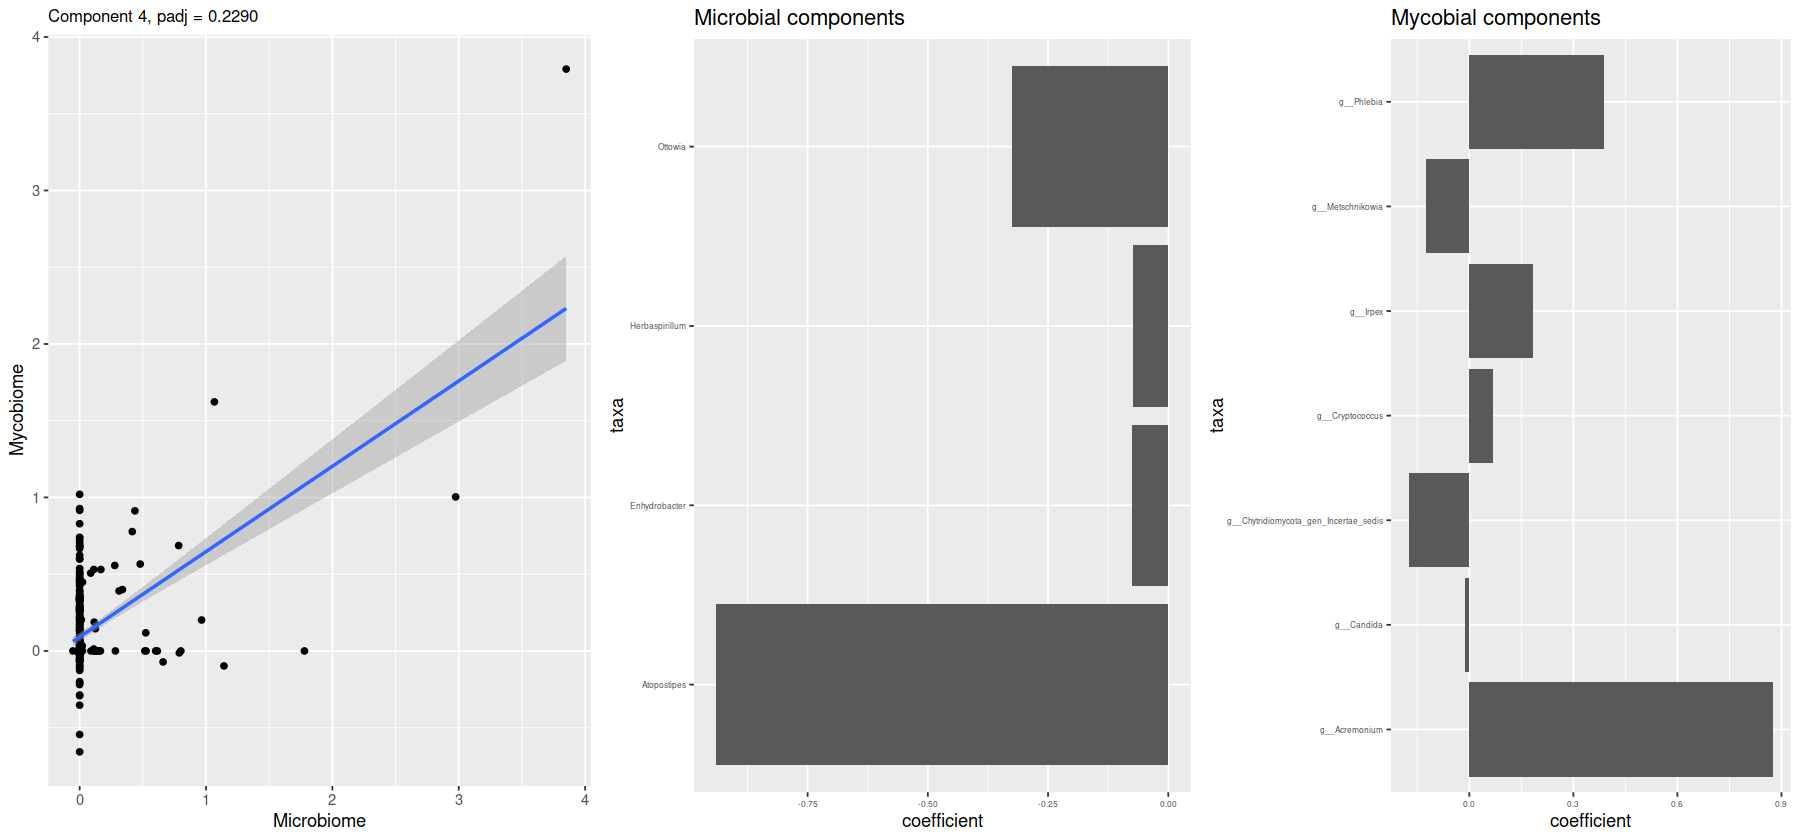

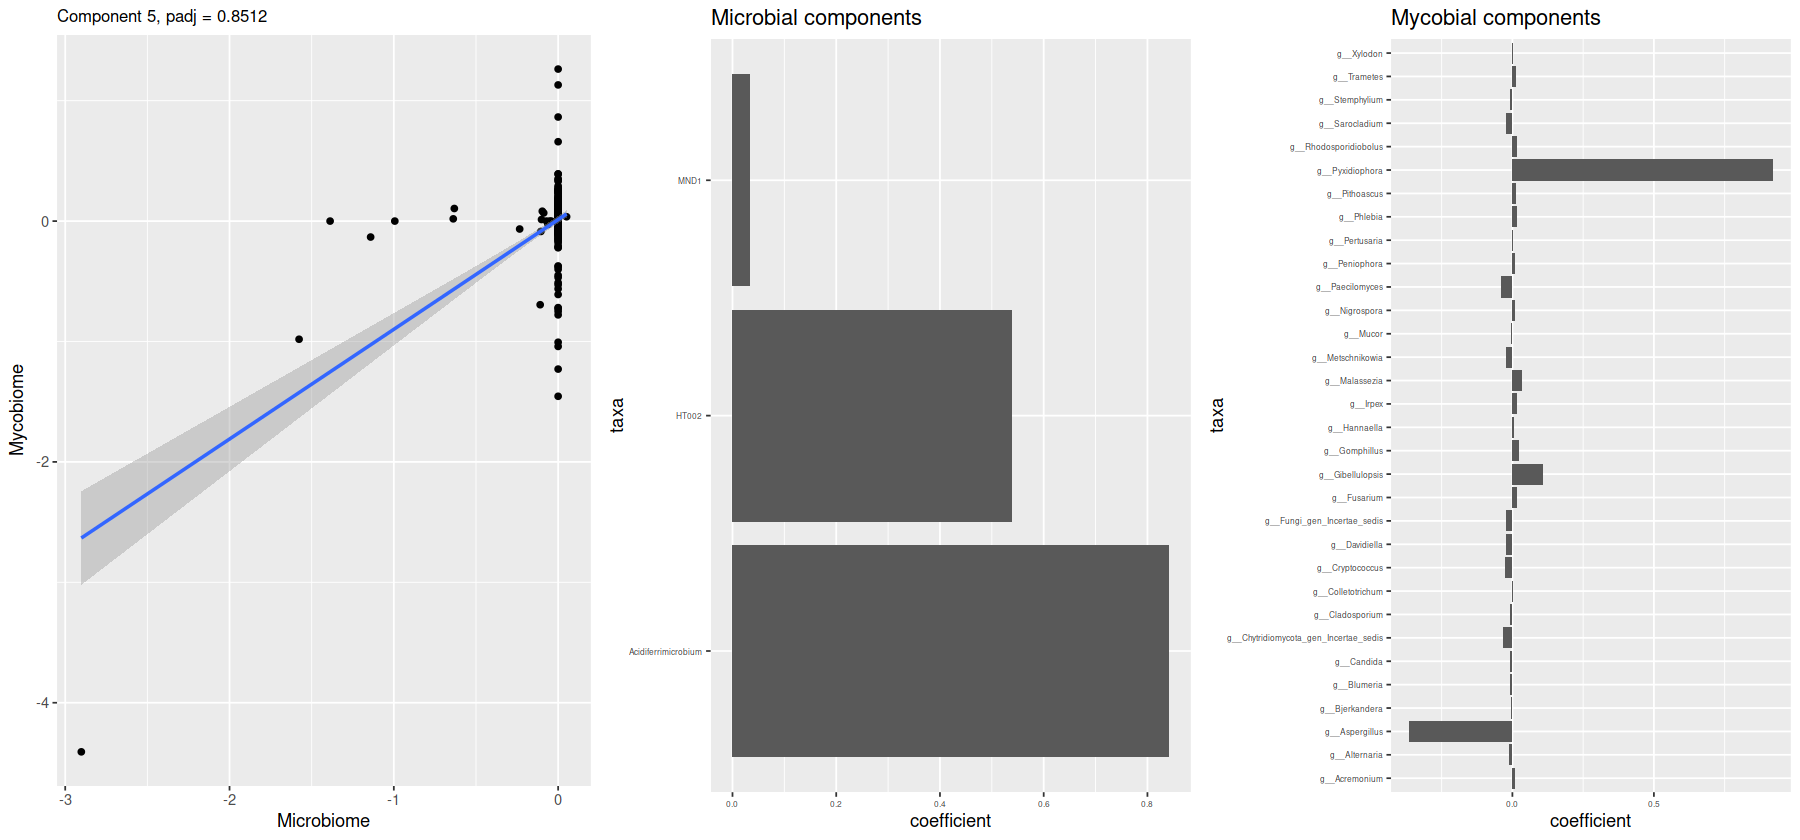

In [40]:
# Visualize each CCA component
width = 15
height = 7
options(repr.plot.width=width, repr.plot.height=height)

for (k in c(1:cca.k)){
    # Subset data for this component
    df_comp_subset <- df_comp[df_comp$component == sprintf("Comp%02d", k), ]
    coefficients_microbiome_subset <- coefficients_microbiome[
        coefficients_microbiome$component == sprintf("Comp%02d", k), ]
    coefficients_mycobiome_subset <- coefficients_mycobiome[
        coefficients_mycobiome$component == sprintf("Comp%02d", k), ]
    
    # Format p-value
    if (CCA_padj[k] < 0.0001){
        padj <- "< 0.0001"
    } else {
        padj <- sprintf("= %.4f", CCA_padj[k])
    }
    
    # Plot correlation between component scores
    plot_cca <- ggplot(df_comp_subset, aes(x = Microbiome, y = Mycobiome)) +
                  geom_point() +
                  geom_smooth(method='lm', formula= y~x) +
                  ggtitle(paste0('Component ', k, ', padj ', padj)) +
                  theme(plot.title=element_text(size=10)) 
    
    # Plot microbiome taxa loadings
    plot_microbiome <- ggplot(coefficients_microbiome_subset, 
                             aes(x = coefficient, y = taxa)) +
                       geom_bar(stat='identity') +
                       theme(axis.text=element_text(size=5)) +
                       ggtitle("Microbial components")
    
    # Plot mycobiome taxa loadings
    plot_mycobiome <- ggplot(coefficients_mycobiome_subset, 
                            aes(x = coefficient, y = taxa)) +
                      geom_bar(stat='identity')  +
                      theme(axis.text=element_text(size=5))+
                      ggtitle("Mycobial components")
    
    # Combine figures together
    p <- ggarrange(plot_cca, plot_microbiome, plot_mycobiome,
              ncol = 3, nrow = 1,
              common.legend = FALSE, legend = "bottom") 
    print(p)
}